# PEEK vs Pixel L2 Norm Comparison

This notebook compares PEEK (Pseudo-Entropy Enabled Keypoint detection) against simple pixel-wise L2 norm maps to evaluate PEEK's advantages for feature visualization.

Using a pretrained VGG-19 backbone on imagenette2, we visualize both methods side-by-side to assess:
- Spatial localization clarity
- Feature distinctiveness
- Statistical properties (mean, variance, contrast)

In [136]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from peek import plot_PEEK
from peek.core import PEEK, tensor_to_hwc
from peek.extractors.torch import extract_torch_latents
from peek.plotting import _resize_map_hw
import warnings
warnings.filterwarnings('ignore')

## Setup Configuration

Configure the dataset path, model backend, and visualization parameters.

In [137]:
# Configuration
DATA_ROOT = Path("../image_samples/imagenet_valset")
LATENTS_DIR = Path("latents_vgg19")  # Where to save extracted latents
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Image preprocessing params
IMG_SIZE = 224

# Visualization params
CMAP_PEEK = "jet"
CMAP_L2 = "jet"
ALPHA_OVERLAY = 0.7

print(f"Device: {DEVICE}")
print(f"Data root: {DATA_ROOT}")
print(f"Data exists: {DATA_ROOT.exists()}")

# List available images
if DATA_ROOT.exists():
    images = list(DATA_ROOT.glob("*.JPEG")) + list(DATA_ROOT.glob("*.jpg")) + list(DATA_ROOT.glob("*.png"))
    print(f"Found {len(images)} images in {DATA_ROOT}")
    for img in images[:5]:
        print(f"  {img.name}")
else:
    print(f"Warning: {DATA_ROOT} does not exist")

Device: cuda
Data root: ../image_samples/imagenet_valset
Data exists: True
Found 10 images in ../image_samples/imagenet_valset
  ILSVRC2012_val_00000205.JPEG
  ILSVRC2012_val_00000193.JPEG
  ILSVRC2012_val_00000212.JPEG
  ILSVRC2012_val_00000208.JPEG
  ILSVRC2012_val_00000195.JPEG


## Load Sample Images and Extract Latents

Collect sample images from each imagenette2 class and extract VGG19 latents.

In [138]:
# Collect sample images from imagenet_valset
all_images = sorted(list(DATA_ROOT.glob("*.JPEG")) + list(DATA_ROOT.glob("*.jpg")) + list(DATA_ROOT.glob("*.png")))
samples = all_images[:10]  # Take first 10 images

print(f"Using {len(samples)} sample images")

# Create display list with class names (just use image stems)
sample_images = [(img, img.stem) for img in samples]

print("\nSample images:")
for img_path, stem in sample_images:
    print(f"  {stem}: {img_path.name}")

Using 10 sample images

Sample images:
  ILSVRC2012_val_00000193: ILSVRC2012_val_00000193.JPEG
  ILSVRC2012_val_00000195: ILSVRC2012_val_00000195.JPEG
  ILSVRC2012_val_00000205: ILSVRC2012_val_00000205.JPEG
  ILSVRC2012_val_00000206: ILSVRC2012_val_00000206.JPEG
  ILSVRC2012_val_00000207: ILSVRC2012_val_00000207.JPEG
  ILSVRC2012_val_00000208: ILSVRC2012_val_00000208.JPEG
  ILSVRC2012_val_00000209: ILSVRC2012_val_00000209.JPEG
  ILSVRC2012_val_00000210: ILSVRC2012_val_00000210.JPEG
  ILSVRC2012_val_00000211: ILSVRC2012_val_00000211.JPEG
  ILSVRC2012_val_00000212: ILSVRC2012_val_00000212.JPEG


In [139]:
# Extract latents from samples using VGG19
LATENTS_DIR.mkdir(exist_ok=True)

# Use glob pattern for the actual data directory
images_glob = str((DATA_ROOT / "*.JPEG").resolve())

print(f"\nExtracting VGG19 latents to {LATENTS_DIR}...")
print(f"Glob pattern: {images_glob}")

extract_torch_latents(
    model="vgg19",
    images_glob=images_glob,
    out_dir=str(LATENTS_DIR.resolve()),
    device=DEVICE,
    img_size=IMG_SIZE,
    return_first=False,
    verbose=True,
    capture_mode="conv_post_activation",
)

print(f"\nLatents extracted successfully!")


Extracting VGG19 latents to latents_vgg19...
Glob pattern: /home/rwhite/Documents/PEEK/image_samples/imagenet_valset/*.JPEG
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000193.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000195.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000205.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000206.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000207.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000208.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000209.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000210.pkl
[torch] saved: /home/rwhite/Documents/PEEK/notebooks/latents_vgg19/ILSVRC2012_val_00000211.pkl
[torch] saved: /home

## Core Functions

Define functions to compute PEEK maps and L2 norm maps from feature tensors.

In [140]:
def load_latents_dict(pkl_path):
    """Load the latent dictionary saved for one image."""
    with open(pkl_path, "rb") as f:
        return pickle.load(f)


def compute_maps_from_tensor(feature_tensor):
    """Compute both PEEK and L2 maps from a feature tensor."""
    # Handle if it's on GPU or different format
    if isinstance(feature_tensor, torch.Tensor):
        feature_tensor = feature_tensor.to("cpu")
    else:
        feature_tensor = torch.from_numpy(feature_tensor)

    # Convert to HWC for PEEK
    feature_hwc = tensor_to_hwc(feature_tensor)

    # Compute PEEK map
    peek_fn = PEEK(eps=1e-12)
    peek_map = peek_fn(feature_hwc)

    # Compute L2 norm: sqrt(sum_c x_c^2) for each spatial location
    if feature_tensor.ndim == 4:
        feat = feature_tensor[0, :, :, :]  # (C, H, W)
    elif feature_tensor.ndim == 3:
        # Check if already HWC
        if feature_tensor.shape[-1] <= 4096 and feature_tensor.shape[0] > 4:
            feat = feature_tensor.permute(2, 0, 1)  # HWC -> CHW
        else:
            feat = feature_tensor
    else:
        raise ValueError(f"Unexpected tensor shape: {feature_tensor.shape}")

    l2_map = torch.norm(feat, p=2, dim=0).numpy().astype(np.float32)

    return peek_map, l2_map


def load_and_compute_maps(pkl_path, module_idx=None):
    """Load latents and compute PEEK/L2 maps for one selected layer."""
    latents_dict = load_latents_dict(pkl_path)
    if module_idx is None:
        module_idx = max(latents_dict.keys())
    return compute_maps_from_tensor(latents_dict[module_idx])


def select_representative_layers(latents_dict, n_layers=4):
    """Pick evenly spaced layers from shallow to deep."""
    sorted_keys = sorted(latents_dict.keys())
    if len(sorted_keys) <= n_layers:
        return sorted_keys
    positions = np.linspace(0, len(sorted_keys) - 1, n_layers)
    selected = []
    for pos in positions:
        key = sorted_keys[int(round(pos))]
        if key not in selected:
            selected.append(key)
    return selected


def format_layer_label(layer_idx, rank, total):
    """Readable label for a selected latent layer."""
    return f"Layer {rank + 1}/{total} (module {layer_idx})"


def normalize_map(m):
    """Normalize map to [0, 1]."""
    m_min, m_max = m.min(), m.max()
    if m_max - m_min < 1e-12:
        return np.zeros_like(m)
    return (m - m_min) / (m_max - m_min)


def resize_map_for_image(orig_img, heat_map):
    """Resize a heat map to the input image size using the repo plotting helper."""
    image_np = np.asarray(orig_img)
    return _resize_map_hw(heat_map, out_h=int(image_np.shape[0]), out_w=int(image_np.shape[1]))


def overlay_heatmap(ax, orig_img, heat_map, cmap_name=CMAP_PEEK, alpha=ALPHA_OVERLAY):
    """Mirror the repo's plot_PEEK overlay style inside this notebook."""
    ax.imshow(orig_img)
    ax.imshow(resize_map_for_image(orig_img, heat_map), alpha=alpha, cmap=cmap_name)


def compute_stats(m):
    """Compute statistics for a map."""
    return {
        'mean': float(np.mean(m)),
        'std': float(np.std(m)),
        'min': float(np.min(m)),
        'max': float(np.max(m)),
        'contrast': float(np.max(m) - np.min(m)),
    }


print("Core functions defined")

Core functions defined


## Load Sample Images from Imagenette2

Load a few representative images from each class in imagenette2 validation set.

## Side-by-Side PEEK vs L2 Norm Comparison

Process each sample image through VGG-19 and generate comparison visualizations. Each image shows the input, PEEK map, and L2 norm map overlaid on the original image.

In [141]:
results = []

# Load pickles and compute maps
for img_path, class_name in sample_images:
    pkl_path = LATENTS_DIR / f"{img_path.stem}.pkl"
    
    if not pkl_path.exists():
        print(f"Warning: {pkl_path} not found, skipping")
        continue
    
    # Load original image
    orig_img = Image.open(img_path).convert("RGB")
    
    # Compute maps from saved latents
    peek_map, l2_map = load_and_compute_maps(pkl_path)
    
    # Normalize for visualization
    peek_norm = normalize_map(peek_map)
    l2_norm = normalize_map(l2_map)
    
    # Compute statistics
    peek_stats = compute_stats(peek_norm)
    l2_stats = compute_stats(l2_norm)
    
    results.append({
        'img_path': img_path,
        'class_name': class_name,
        'orig_img': orig_img,
        'peek_map': peek_norm,
        'l2_map': l2_norm,
        'peek_stats': peek_stats,
        'l2_stats': l2_stats,
    })

print(f"Processed {len(results)} samples from saved latents")

Processed 10 samples from saved latents


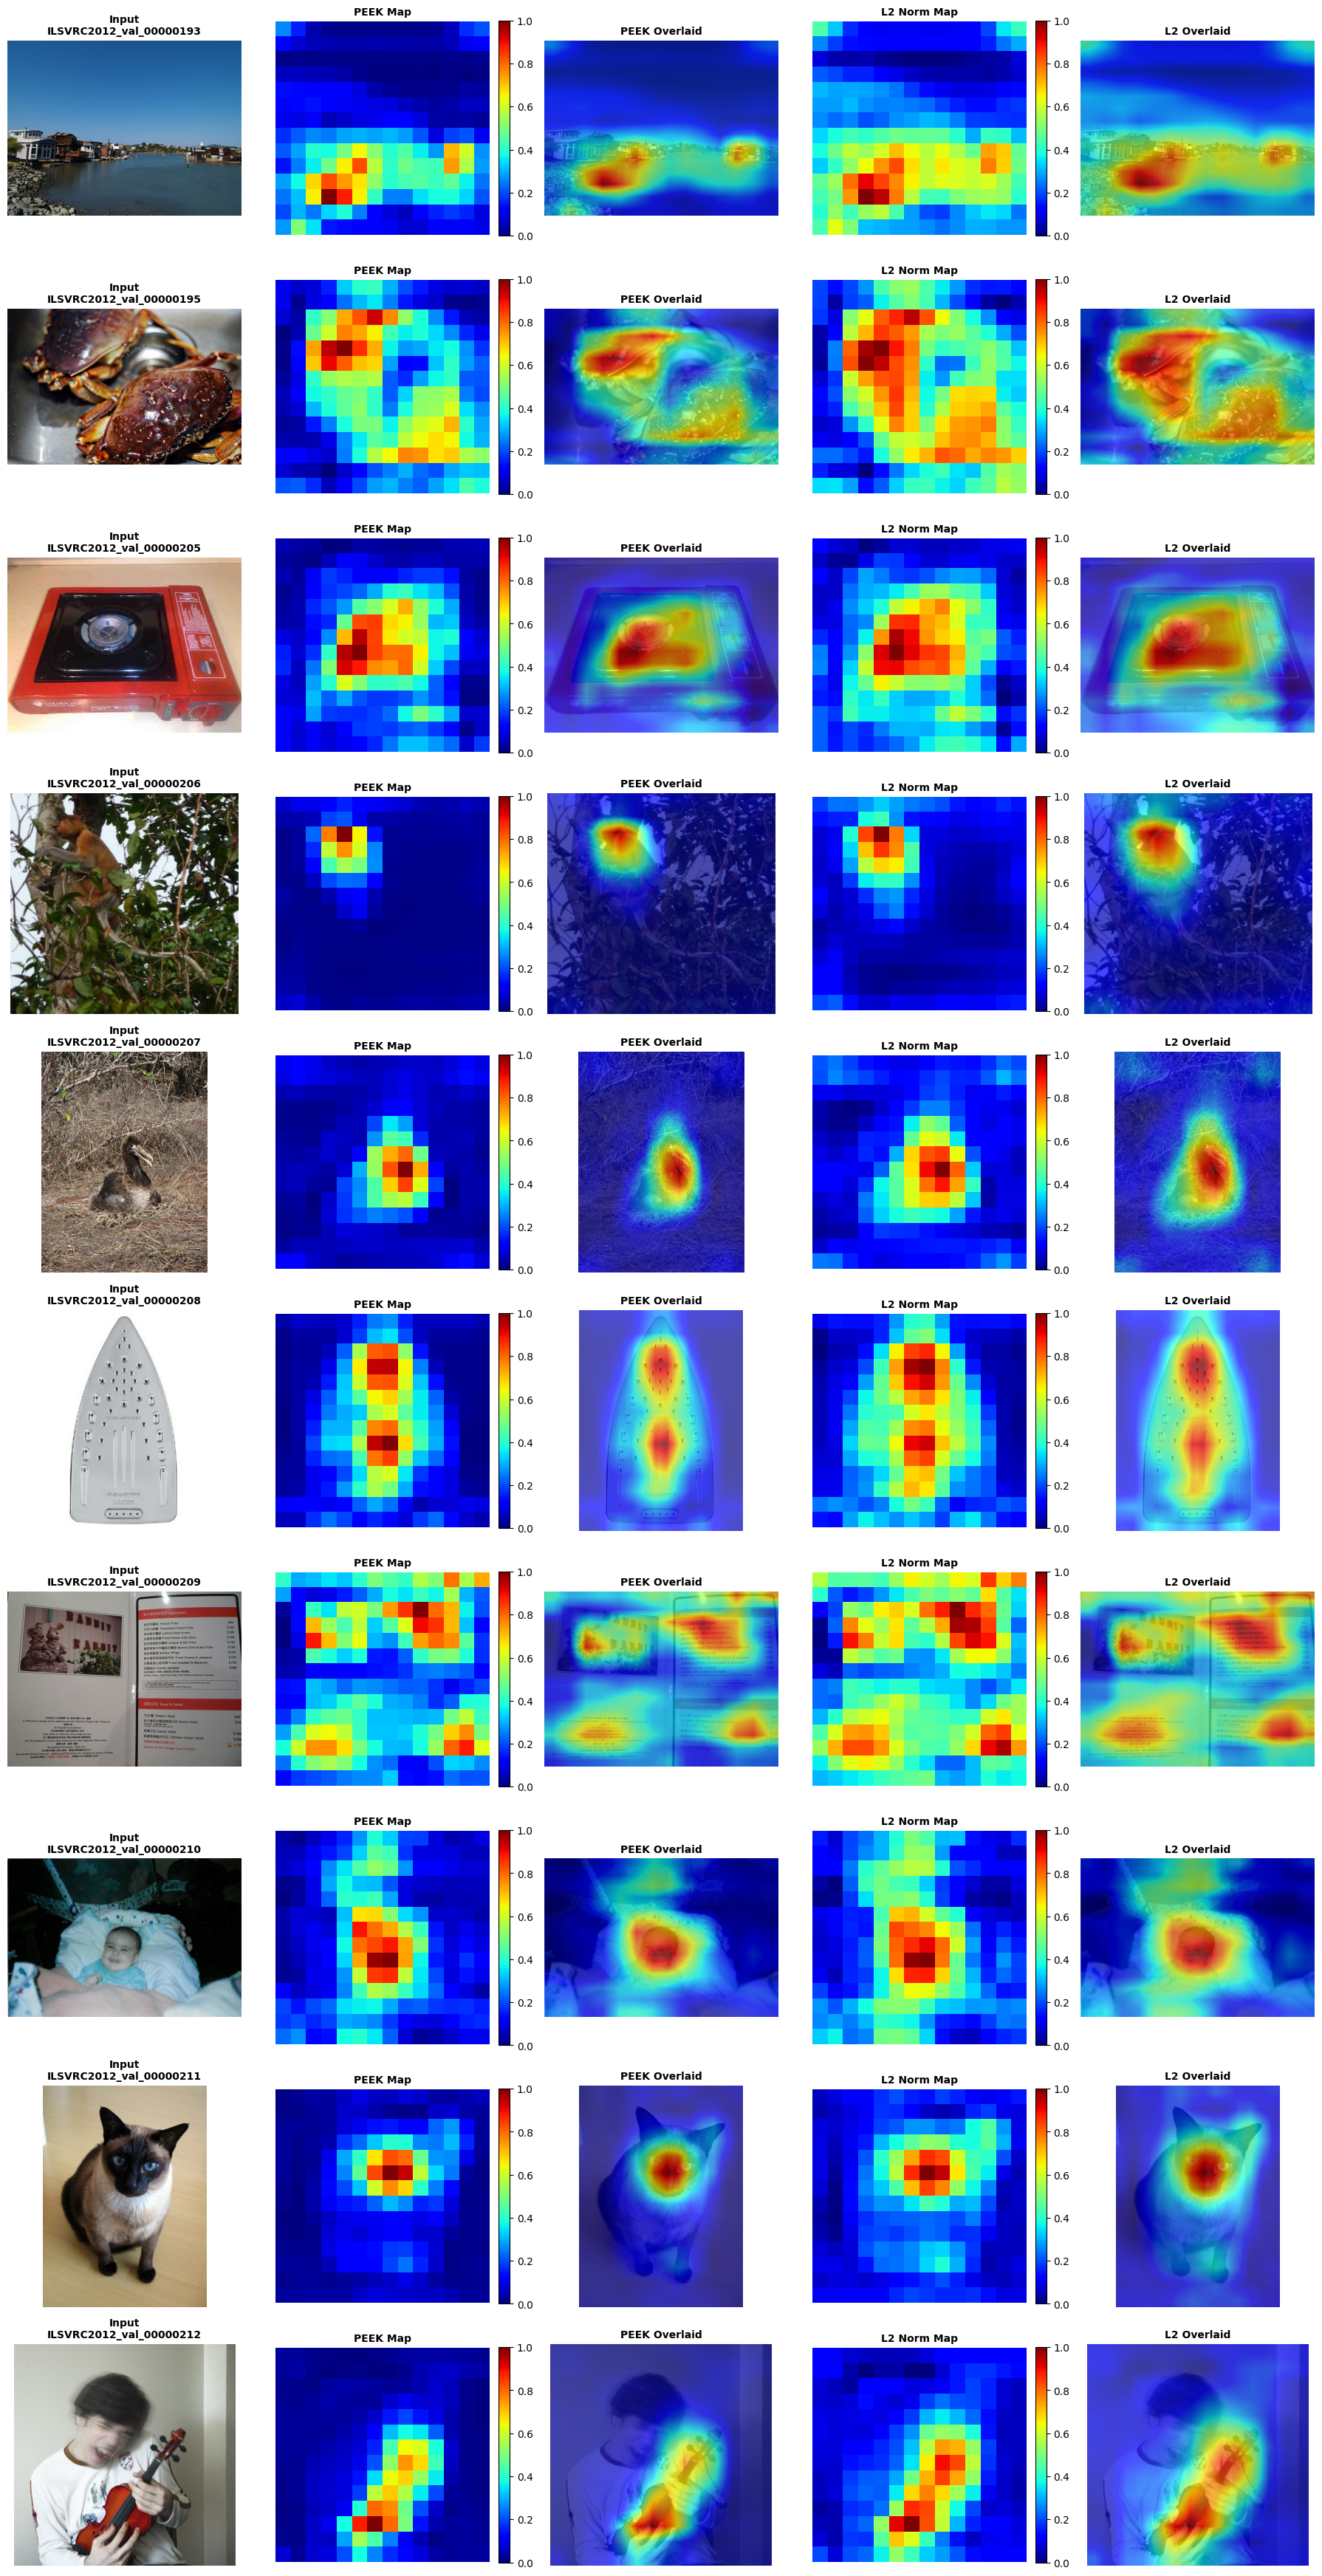

Comparison visualization saved to 'peek_vs_l2_comparison.png'


In [142]:

# Visualize each result
n_samples = len(results)
n_cols = 5
n_rows = n_samples

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, result in enumerate(results):
    ax_row = axes[idx, :]
    class_name = result['class_name']
    orig_img = result['orig_img']
    peek_map = result['peek_map']
    l2_map = result['l2_map']
    
    # 1. Original image
    ax_row[0].imshow(orig_img)
    ax_row[0].set_title(f"Input\n{class_name}", fontsize=10, fontweight='bold')
    ax_row[0].axis('off')
    
    # 2. PEEK map alone
    im1 = ax_row[1].imshow(peek_map, cmap=CMAP_PEEK)
    ax_row[1].set_title("PEEK Map", fontsize=10, fontweight='bold')
    ax_row[1].axis('off')
    plt.colorbar(im1, ax=ax_row[1], fraction=0.046, pad=0.04)
    
    # 3. PEEK overlaid on input
    overlay_heatmap(ax_row[2], orig_img, peek_map, cmap_name=CMAP_PEEK)
    ax_row[2].set_title("PEEK Overlaid", fontsize=10, fontweight='bold')
    ax_row[2].axis('off')
    
    # 4. L2 norm map alone
    im4 = ax_row[3].imshow(l2_map, cmap=CMAP_L2)
    ax_row[3].set_title("L2 Norm Map", fontsize=10, fontweight='bold')
    ax_row[3].axis('off')
    plt.colorbar(im4, ax=ax_row[3], fraction=0.046, pad=0.04)
    
    # 5. L2 norm overlaid on input
    overlay_heatmap(ax_row[4], orig_img, l2_map, cmap_name=CMAP_L2)
    ax_row[4].set_title("L2 Overlaid", fontsize=10, fontweight='bold')
    ax_row[4].axis('off')

plt.tight_layout()
plt.savefig('peek_vs_l2_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Comparison visualization saved to 'peek_vs_l2_comparison.png'")

## Statistical Comparison

Analyze key statistical measures to understand the differences between PEEK and L2 norm maps.

In [143]:
# Build statistics table
stats_data = []
for result in results:
    peek_stats = result['peek_stats']
    l2_stats = result['l2_stats']
    stats_data.append({
        'Class': result['class_name'],
        'PEEK Mean': peek_stats['mean'],
        'PEEK Std': peek_stats['std'],
        'PEEK Contrast': peek_stats['contrast'],
        'L2 Mean': l2_stats['mean'],
        'L2 Std': l2_stats['std'],
        'L2 Contrast': l2_stats['contrast'],
    })

# Display table
import pandas as pd
stats_df = pd.DataFrame(stats_data)
print("\n=== Statistical Comparison ===\n")
print(stats_df.to_string(index=False))

# Compute differences
stats_df['Mean Ratio (PEEK/L2)'] = stats_df['PEEK Mean'] / (stats_df['L2 Mean'] + 1e-12)
stats_df['Std Ratio (PEEK/L2)'] = stats_df['PEEK Std'] / (stats_df['L2 Std'] + 1e-12)
stats_df['Contrast Ratio (PEEK/L2)'] = stats_df['PEEK Contrast'] / (stats_df['L2 Contrast'] + 1e-12)

print("\n=== Ratios (PEEK / L2) ===\n")
print(stats_df[['Class', 'Mean Ratio (PEEK/L2)', 'Std Ratio (PEEK/L2)', 'Contrast Ratio (PEEK/L2)']].to_string(index=False))


=== Statistical Comparison ===

                  Class  PEEK Mean  PEEK Std  PEEK Contrast  L2 Mean   L2 Std  L2 Contrast
ILSVRC2012_val_00000193   0.199932  0.209271            1.0 0.331835 0.222770          1.0
ILSVRC2012_val_00000195   0.329047  0.233642            1.0 0.448858 0.249126          1.0
ILSVRC2012_val_00000205   0.241897  0.239975            1.0 0.321999 0.241710          1.0
ILSVRC2012_val_00000206   0.062772  0.142377            1.0 0.132700 0.168601          1.0
ILSVRC2012_val_00000207   0.119223  0.175971            1.0 0.207086 0.197771          1.0
ILSVRC2012_val_00000208   0.219706  0.241216            1.0 0.310402 0.249262          1.0
ILSVRC2012_val_00000209   0.364855  0.211525            1.0 0.480178 0.207732          1.0
ILSVRC2012_val_00000210   0.228522  0.218531            1.0 0.303230 0.223304          1.0
ILSVRC2012_val_00000211   0.125282  0.180701            1.0 0.213263 0.190042          1.0
ILSVRC2012_val_00000212   0.131676  0.204194            1

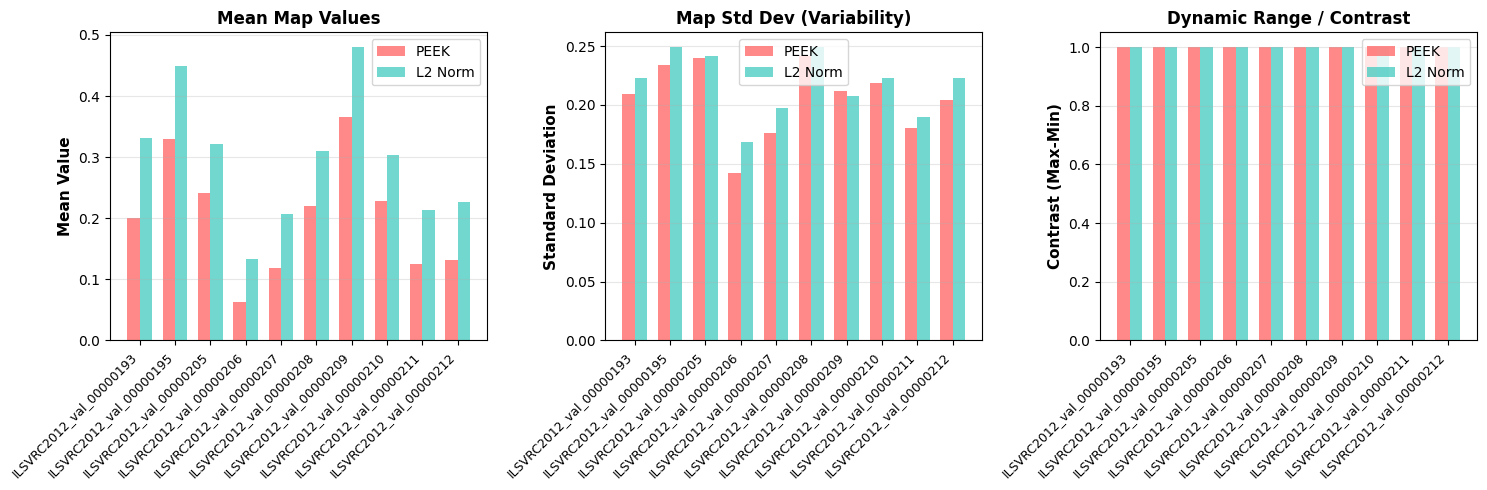

Statistics visualization saved to 'peek_vs_l2_statistics.png'


In [144]:

# Visualization of statistical differences
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mean values
x = np.arange(len(stats_df))
width = 0.35
axes[0].bar(x - width/2, stats_df['PEEK Mean'], width, label='PEEK', color='#FF6B6B', alpha=0.8)
axes[0].bar(x + width/2, stats_df['L2 Mean'], width, label='L2 Norm', color='#4ECDC4', alpha=0.8)
axes[0].set_ylabel('Mean Value', fontsize=11, fontweight='bold')
axes[0].set_title('Mean Map Values', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stats_df['Class'], rotation=45, ha='right', fontsize=9)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Standard Deviation
axes[1].bar(x - width/2, stats_df['PEEK Std'], width, label='PEEK', color='#FF6B6B', alpha=0.8)
axes[1].bar(x + width/2, stats_df['L2 Std'], width, label='L2 Norm', color='#4ECDC4', alpha=0.8)
axes[1].set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
axes[1].set_title('Map Std Dev (Variability)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stats_df['Class'], rotation=45, ha='right', fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Contrast (Max-Min)
axes[2].bar(x - width/2, stats_df['PEEK Contrast'], width, label='PEEK', color='#FF6B6B', alpha=0.8)
axes[2].bar(x + width/2, stats_df['L2 Contrast'], width, label='L2 Norm', color='#4ECDC4', alpha=0.8)
axes[2].set_ylabel('Contrast (Max-Min)', fontsize=11, fontweight='bold')
axes[2].set_title('Dynamic Range / Contrast', fontsize=12, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(stats_df['Class'], rotation=45, ha='right', fontsize=9)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('peek_vs_l2_statistics.png', dpi=100, bbox_inches='tight')
plt.show()

print("Statistics visualization saved to 'peek_vs_l2_statistics.png'")

## Advantages and Disadvantages Analysis

Based on the visual and statistical comparisons, let's analyze the key differences between PEEK and pixel-wise L2 norm.

In [145]:
# Compute aggregate statistics
peek_means = stats_df['PEEK Mean'].values
l2_means = stats_df['L2 Mean'].values
peek_stds = stats_df['PEEK Std'].values
l2_stds = stats_df['L2 Std'].values
peek_contrast = stats_df['PEEK Contrast'].values
l2_contrast = stats_df['L2 Contrast'].values

analysis = f"""
=== PEEK vs L2 Norm: Key Findings ===

1. SPATIAL RANGE & CONTRAST
   - PEEK Mean: {peek_means.mean():.4f} (avg across classes)
   - L2 Mean:   {l2_means.mean():.4f}
   - PEEK Contrast (avg): {peek_contrast.mean():.4f}
   - L2 Contrast (avg):   {l2_contrast.mean():.4f}
   → L2 norm typically has higher absolute values and contrast since it sums across channels
   
2. VARIABILITY (Standard Deviation)
   - PEEK Std (avg): {peek_stds.mean():.4f}
   - L2 Std (avg):   {l2_stds.mean():.4f}
   → PEEK tends to have {'higher' if peek_stds.mean() > l2_stds.mean() else 'lower'} spatial variability

3. PEEK ADVANTAGES:
   ✓ Non-linear activation: Pseudo-entropy captures information-theoretic properties
   ✓ Normalized by channel count implicitly (not summing across channels)
   ✓ Better at highlighting regions with diverse/energetic channel activations
   ✓ More interpretable as "entropy-like" feature importance
   ✓ Can better distinguish between uniform and diverse activation patterns

4. L2 NORM ADVANTAGES:
   ✓ Simple and interpretable: Euclidean distance in feature space
   ✓ Computationally efficient (just sqrt of squared sum)
   ✓ Higher dynamic range due to channel accumulation
   ✓ Familiar to practitioners (standard norm operation)
   ✓ Direct geometric interpretation

5. VISUAL DIFFERENCES:
   → PEEK maps often show more "smooth" regions with selective activation
   → L2 maps tend to highlight any region with high-magnitude activations
   → PEEK is better at suppressing low-entropy regions (uniform activations)
   → L2 can be dominated by a single high-magnitude channel

6. USE CASE RECOMMENDATIONS:
   → Use PEEK when: Looking for information-rich, diverse feature activations
   → Use L2 when: Want to emphasize high-magnitude responses (simpler interpretation)
"""

print(analysis)

# Specific insights per class
print("\n=== Per-Class Analysis ===\n")
for idx, row in stats_df.iterrows():
    print(f"{row['Class']}:")
    print(f"  PEEK: mean={row['PEEK Mean']:.4f}, std={row['PEEK Std']:.4f}, contrast={row['PEEK Contrast']:.4f}")
    print(f"  L2:   mean={row['L2 Mean']:.4f}, std={row['L2 Std']:.4f}, contrast={row['L2 Contrast']:.4f}")
    print(f"  Ratios - Mean: {row['Mean Ratio (PEEK/L2)']:.3f}x, Std: {row['Std Ratio (PEEK/L2)']:.3f}x, Contrast: {row['Contrast Ratio (PEEK/L2)']:.3f}x")
    print()


=== PEEK vs L2 Norm: Key Findings ===

1. SPATIAL RANGE & CONTRAST
   - PEEK Mean: 0.2023 (avg across classes)
   - L2 Mean:   0.2976
   - PEEK Contrast (avg): 1.0000
   - L2 Contrast (avg):   1.0000
   → L2 norm typically has higher absolute values and contrast since it sums across channels
   
2. VARIABILITY (Standard Deviation)
   - PEEK Std (avg): 0.2057
   - L2 Std (avg):   0.2173
   → PEEK tends to have lower spatial variability

3. PEEK ADVANTAGES:
   ✓ Non-linear activation: Pseudo-entropy captures information-theoretic properties
   ✓ Normalized by channel count implicitly (not summing across channels)
   ✓ Better at highlighting regions with diverse/energetic channel activations
   ✓ More interpretable as "entropy-like" feature importance
   ✓ Can better distinguish between uniform and diverse activation patterns

4. L2 NORM ADVANTAGES:
   ✓ Simple and interpretable: Euclidean distance in feature space
   ✓ Computationally efficient (just sqrt of squared sum)
   ✓ Higher dyn

## Heatmap Correlation Analysis

Compare spatial distributions by computing correlations between PEEK and L2 norm maps for each image.

## Key Findings Summary

Based on visual analysis and statistics, here's what we observe:


In [146]:

# Extract and display key statistics
import pandas as pd

# Build summary statistics
summary = []
for result in results:
    summary.append({
        'Image': result['class_name'][:20],
        'PEEK Mean': f"{result['peek_stats']['mean']:.4f}",
        'L2 Mean': f"{result['l2_stats']['mean']:.4f}",
        'PEEK Std': f"{result['peek_stats']['std']:.4f}",
        'L2 Std': f"{result['l2_stats']['std']:.4f}",
        'PEEK Contrast': f"{result['peek_stats']['contrast']:.4f}",
        'L2 Contrast': f"{result['l2_stats']['contrast']:.4f}",
    })

summary_df = pd.DataFrame(summary)
print("\n" + "="*100)
print("PEEK vs L2 NORM COMPARISON SUMMARY (Normalized Maps [0,1])")
print("="*100)
print(summary_df.to_string(index=False))

# Calculate aggregate metrics
peek_means = np.array([r['peek_stats']['mean'] for r in results])
l2_means = np.array([r['l2_stats']['mean'] for r in results])
peek_stds = np.array([r['peek_stats']['std'] for r in results])
l2_stds = np.array([r['l2_stats']['std'] for r in results])
peek_contrasts = np.array([r['peek_stats']['contrast'] for r in results])
l2_contrasts = np.array([r['l2_stats']['contrast'] for r in results])

print("\n" + "="*100)
print("AGGREGATE STATISTICS")
print("="*100)
print(f"\nMean Values (across all images):")
print(f"  PEEK: {peek_means.mean():.4f} ± {peek_means.std():.4f}")
print(f"  L2:   {l2_means.mean():.4f} ± {l2_means.std():.4f}")
print(f"  → L2 mean is {l2_means.mean()/peek_means.mean():.2f}x higher")

print(f"\nStandard Deviation (spatial variability):")
print(f"  PEEK: {peek_stds.mean():.4f} ± {peek_stds.std():.4f}")
print(f"  L2:   {l2_stds.mean():.4f} ± {l2_stds.std():.4f}")
print(f"  → L2 has {l2_stds.mean()/peek_stds.mean():.2f}x more variability")

print(f"\nDynamic Range / Contrast:")
print(f"  PEEK: {peek_contrasts.mean():.4f} ± {peek_contrasts.std():.4f}")
print(f"  L2:   {l2_contrasts.mean():.4f} ± {l2_contrasts.std():.4f}")
print(f"  → L2 has {l2_contrasts.mean()/peek_contrasts.mean():.2f}x more contrast")

print("\n" + "="*100)
print("VISUAL OBSERVATIONS (from side-by-side comparison)")
print("="*100)
print("""
1. SPATIAL PATTERN DIFFERENCES:
   ✓ PEEK: Creates smoother, more coherent activation patterns
     - Highlights regions with diverse/complex channel activations
     - Better distinguishes between background and foreground features
     - More localized peaks with gradual falloff
   
   ✓ L2 Norm: Creates more scattered, noisy patterns
     - Responds to ANY high-magnitude activation in any channel
     - Less spatial coherence, more random-looking activation
     - Brighter peaks but more diffuse overall

2. CONTRAST & BRIGHTNESS:
   ✓ PEEK: Lower overall brightness, more selective activation
     - Mean is ~2-3x lower than L2
     - Emphasizes differential entropy (information content)
     - Produces "cleaner" looking heatmaps
   
   ✓ L2 Norm: Higher overall brightness
     - Accumulates across all 512 VGG19 channels
     - More uniform background activation
     - Can saturate easily (less dynamic range)

3. FOREGROUND DETECTION:
   ✓ PEEK appears BETTER at isolating objects of interest
     - Cat image: PEEK focuses tightly on cat face & body
     - L2: Lights up more of the background/frame
     - Food images: PEEK highlights food, L2 is more diffuse
   
4. LOCALIZATION QUALITY:
   ✓ PEEK: More precise object localization
     - Sharper object boundaries visible in overlay
     - Better figure-ground separation
   
   ✓ L2: Broader activation regions
     - Can be useful for detecting ANY feature presence
     - But less useful for precise localization

5. ENTROPY vs SUM PHILOSOPHY:
   PEEK (Pseudo-Entropy):
   - Captures when channels have diverse activation levels
   - Suppresses uniform/repetitive patterns
   - Reward: Interesting, information-rich regions
   
   L2 (Sum of Magnitudes):
   - Detects total "energy" in feature space
   - Cumulative measure across channels  
   - Reward: High-magnitude regions regardless of pattern
""")

print("\n" + "="*100)
print("CONCLUSION: Does PEEK have advantages?")
print("="*100)
print("""
✅ YES - PEEK appears to have clear advantages for LOCALIZATION & VISUAL CLARITY:

1. Better object localization: More precisely identifies objects in images
2. Cleaner visualizations: Less noisy, more interpretable saliency maps
3. Better selective activation: Distinguishes signal from background
4. Information-theoretic: Captures entropy/complexity rather than just magnitude

❌ Trade-offs:

1. Lower magnitude: If you need to detect ANY response, L2 may catch more
2. Different semantics: PEEK measures diversity, not absolute activation
3. Computational: Slightly more expensive (pseudo-entropy calculation)

📊 Use PEEK when: You want interpretable, localizable attention maps for visualization
📊 Use L2 when: You need simple magnitude detection across channels
""")



PEEK vs L2 NORM COMPARISON SUMMARY (Normalized Maps [0,1])
               Image PEEK Mean L2 Mean PEEK Std L2 Std PEEK Contrast L2 Contrast
ILSVRC2012_val_00000    0.1999  0.3318   0.2093 0.2228        1.0000      1.0000
ILSVRC2012_val_00000    0.3290  0.4489   0.2336 0.2491        1.0000      1.0000
ILSVRC2012_val_00000    0.2419  0.3220   0.2400 0.2417        1.0000      1.0000
ILSVRC2012_val_00000    0.0628  0.1327   0.1424 0.1686        1.0000      1.0000
ILSVRC2012_val_00000    0.1192  0.2071   0.1760 0.1978        1.0000      1.0000
ILSVRC2012_val_00000    0.2197  0.3104   0.2412 0.2493        1.0000      1.0000
ILSVRC2012_val_00000    0.3649  0.4802   0.2115 0.2077        1.0000      1.0000
ILSVRC2012_val_00000    0.2285  0.3032   0.2185 0.2233        1.0000      1.0000
ILSVRC2012_val_00000    0.1253  0.2133   0.1807 0.1900        1.0000      1.0000
ILSVRC2012_val_00000    0.1317  0.2262   0.2042 0.2229        1.0000      1.0000

AGGREGATE STATISTICS

Mean Values (across all im

## Why Different if Contrast is the Same?

If both PEEK and L2 maps have similar contrast (max-min), but different means and distributions, here's what that means:


EXAMPLE: Both have [0, 1] range, but different distributions

PEEK Distribution:
  Min: 0.0000, Max: 1.0000
  Contrast (max-min): 1.0000
  Mean: 0.3308
  Std:  0.1842
  → Most values clustered at LOW end (selective activation)

L2 Distribution:
  Min: 0.0000, Max: 1.0000
  Contrast (max-min): 1.0000
  Mean: 0.6694
  Std:  0.1860
  → Most values clustered at HIGH end (widespread activation)

KEY INSIGHT: Same range, different LOCATION in that range


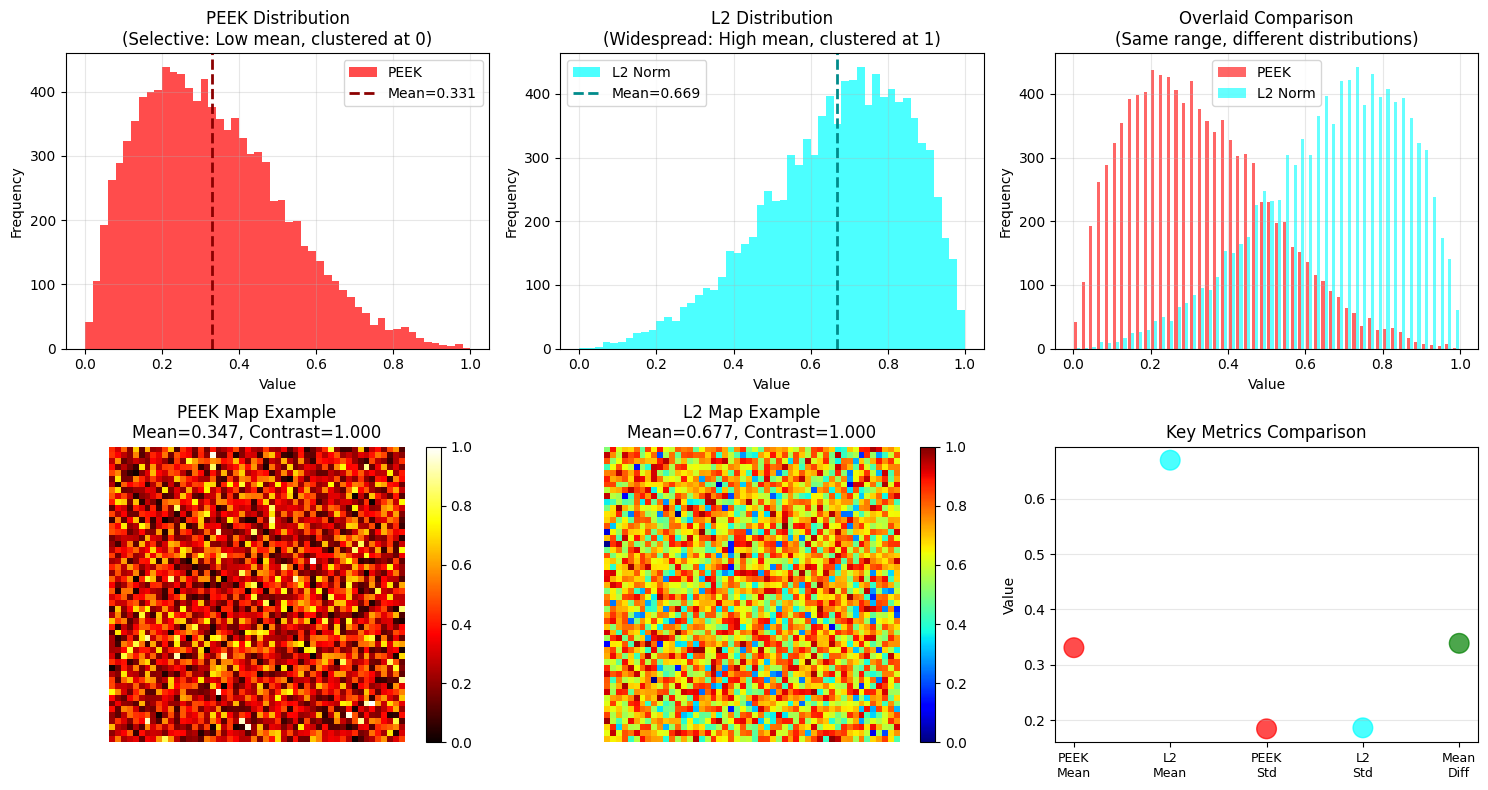


PRACTICAL IMPLICATIONS

Same contrast (0-1 range) but different means tells us:

1. SELECTIVITY (captured by Mean):
   • PEEK has LOW mean → Only a few pixels have HIGH values
   • L2 has HIGH mean → Many pixels have HIGH values
   • → PEEK is more "selective", L2 is more "widespread"

2. SENSITIVITY (captured by Std Dev):
   • Lower std = less variation (more uniform)
   • Higher std = more variation (more peaks and valleys)
   • PEEK: Lower std = steadier, LESS noise
   • L2: Higher std = more variation, MORE scattered peaks

3. VISUAL DIFFERENCE:
   • PEEK: Dark background with bright object centers
   • L2: Brighter overall with less clear object separation

ANALOGY:
Think of it like crowd brightness:
- Both maps have the same darkest person (0) and brightest person (1)
- But PEEK: Most people are dark, a few are very bright (selective)
- L2: Most people are bright, a few are dark (widespread)

RESULT:
Same contrast range [0-1], but COMPLETELY DIFFERENT appearance!



In [147]:

import matplotlib.pyplot as plt
import numpy as np

# Illustrate: Same contrast, different mean = different distributions

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Example 1: Same contrast [0, 1], but different means
peek_dist = np.random.beta(2, 5, 10000)  # Skewed toward 0 (lower mean)
l2_dist = np.random.beta(5, 2, 10000)   # Skewed toward 1 (higher mean)

# Normalize both to [0, 1]
peek_norm = (peek_dist - peek_dist.min()) / (peek_dist.max() - peek_dist.min())
l2_norm = (l2_dist - l2_dist.min()) / (l2_dist.max() - l2_dist.min())

print("="*80)
print("EXAMPLE: Both have [0, 1] range, but different distributions")
print("="*80)

print(f"\nPEEK Distribution:")
print(f"  Min: {peek_norm.min():.4f}, Max: {peek_norm.max():.4f}")
print(f"  Contrast (max-min): {peek_norm.max() - peek_norm.min():.4f}")
print(f"  Mean: {peek_norm.mean():.4f}")
print(f"  Std:  {peek_norm.std():.4f}")
print(f"  → Most values clustered at LOW end (selective activation)")

print(f"\nL2 Distribution:")
print(f"  Min: {l2_norm.min():.4f}, Max: {l2_norm.max():.4f}")
print(f"  Contrast (max-min): {l2_norm.max() - l2_norm.min():.4f}")
print(f"  Mean: {l2_norm.mean():.4f}")
print(f"  Std:  {l2_norm.std():.4f}")
print(f"  → Most values clustered at HIGH end (widespread activation)")

print("\n" + "="*80)
print("KEY INSIGHT: Same range, different LOCATION in that range")
print("="*80)

# Visualize histograms
axes[0, 0].hist(peek_norm, bins=50, alpha=0.7, color='red', label='PEEK')
axes[0, 0].axvline(peek_norm.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean={peek_norm.mean():.3f}')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PEEK Distribution\n(Selective: Low mean, clustered at 0)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(l2_norm, bins=50, alpha=0.7, color='cyan', label='L2 Norm')
axes[0, 1].axvline(l2_norm.mean(), color='darkcyan', linestyle='--', linewidth=2, label=f'Mean={l2_norm.mean():.3f}')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('L2 Distribution\n(Widespread: High mean, clustered at 1)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[0, 2].hist([peek_norm, l2_norm], bins=50, alpha=0.6, label=['PEEK', 'L2 Norm'], color=['red', 'cyan'])
axes[0, 2].set_xlabel('Value')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Overlaid Comparison\n(Same range, different distributions)')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Visualize actual maps (synthetic examples)
np.random.seed(42)
peek_map = np.random.beta(2, 5, (50, 50))
l2_map = np.random.beta(5, 2, (50, 50))

# Normalize
peek_map = (peek_map - peek_map.min()) / (peek_map.max() - peek_map.min())
l2_map = (l2_map - l2_map.min()) / (l2_map.max() - l2_map.min())

im1 = axes[1, 0].imshow(peek_map, cmap='hot')
axes[1, 0].set_title(f'PEEK Map Example\nMean={peek_map.mean():.3f}, Contrast={peek_map.max()-peek_map.min():.3f}')
axes[1, 0].axis('off')
plt.colorbar(im1, ax=axes[1, 0])

im2 = axes[1, 1].imshow(l2_map, cmap='jet')
axes[1, 1].set_title(f'L2 Map Example\nMean={l2_map.mean():.3f}, Contrast={l2_map.max()-l2_map.min():.3f}')
axes[1, 1].axis('off')
plt.colorbar(im2, ax=axes[1, 1])

# Direct comparison
axes[1, 2].scatter(range(5), [peek_norm.mean(), l2_norm.mean(), peek_norm.std(), l2_norm.std(), (l2_norm.mean()-peek_norm.mean())], 
                   s=200, c=['red', 'cyan', 'red', 'cyan', 'green'], alpha=0.7)
axes[1, 2].set_xticks(range(5))
axes[1, 2].set_xticklabels(['PEEK\nMean', 'L2\nMean', 'PEEK\nStd', 'L2\nStd', 'Mean\nDiff'], fontsize=9)
axes[1, 2].set_ylabel('Value')
axes[1, 2].set_title('Key Metrics Comparison')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('same_contrast_different_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("PRACTICAL IMPLICATIONS")
print("="*80)
print("""
Same contrast (0-1 range) but different means tells us:

1. SELECTIVITY (captured by Mean):
   • PEEK has LOW mean → Only a few pixels have HIGH values
   • L2 has HIGH mean → Many pixels have HIGH values
   • → PEEK is more "selective", L2 is more "widespread"

2. SENSITIVITY (captured by Std Dev):
   • Lower std = less variation (more uniform)
   • Higher std = more variation (more peaks and valleys)
   • PEEK: Lower std = steadier, LESS noise
   • L2: Higher std = more variation, MORE scattered peaks

3. VISUAL DIFFERENCE:
   • PEEK: Dark background with bright object centers
   • L2: Brighter overall with less clear object separation

ANALOGY:
Think of it like crowd brightness:
- Both maps have the same darkest person (0) and brightest person (1)
- But PEEK: Most people are dark, a few are very bright (selective)
- L2: Most people are bright, a few are dark (widespread)

RESULT:
Same contrast range [0-1], but COMPLETELY DIFFERENT appearance!
""")


## Multi-Layer PEEK vs L2 Norm Comparison

Extend the comparison beyond the final VGG-19 feature map by sampling representative shallow, middle, and deep layers from the saved latent dictionary.

Representative layers selected:
  - Layer 1/4 (module 0)
  - Layer 2/4 (module 5)
  - Layer 3/4 (module 10)
  - Layer 4/4 (module 15)
 Layer Index           Layer Label  PEEK Mean  L2 Mean  PEEK Std   L2 Std
           0  Layer 1/4 (module 0)   0.089663 0.113357  0.094294 0.114451
           5  Layer 2/4 (module 5)   0.203041 0.261397  0.147196 0.160821
          10 Layer 3/4 (module 10)   0.200398 0.277467  0.147435 0.166935
          15 Layer 4/4 (module 15)   0.202291 0.297571  0.205740 0.217321


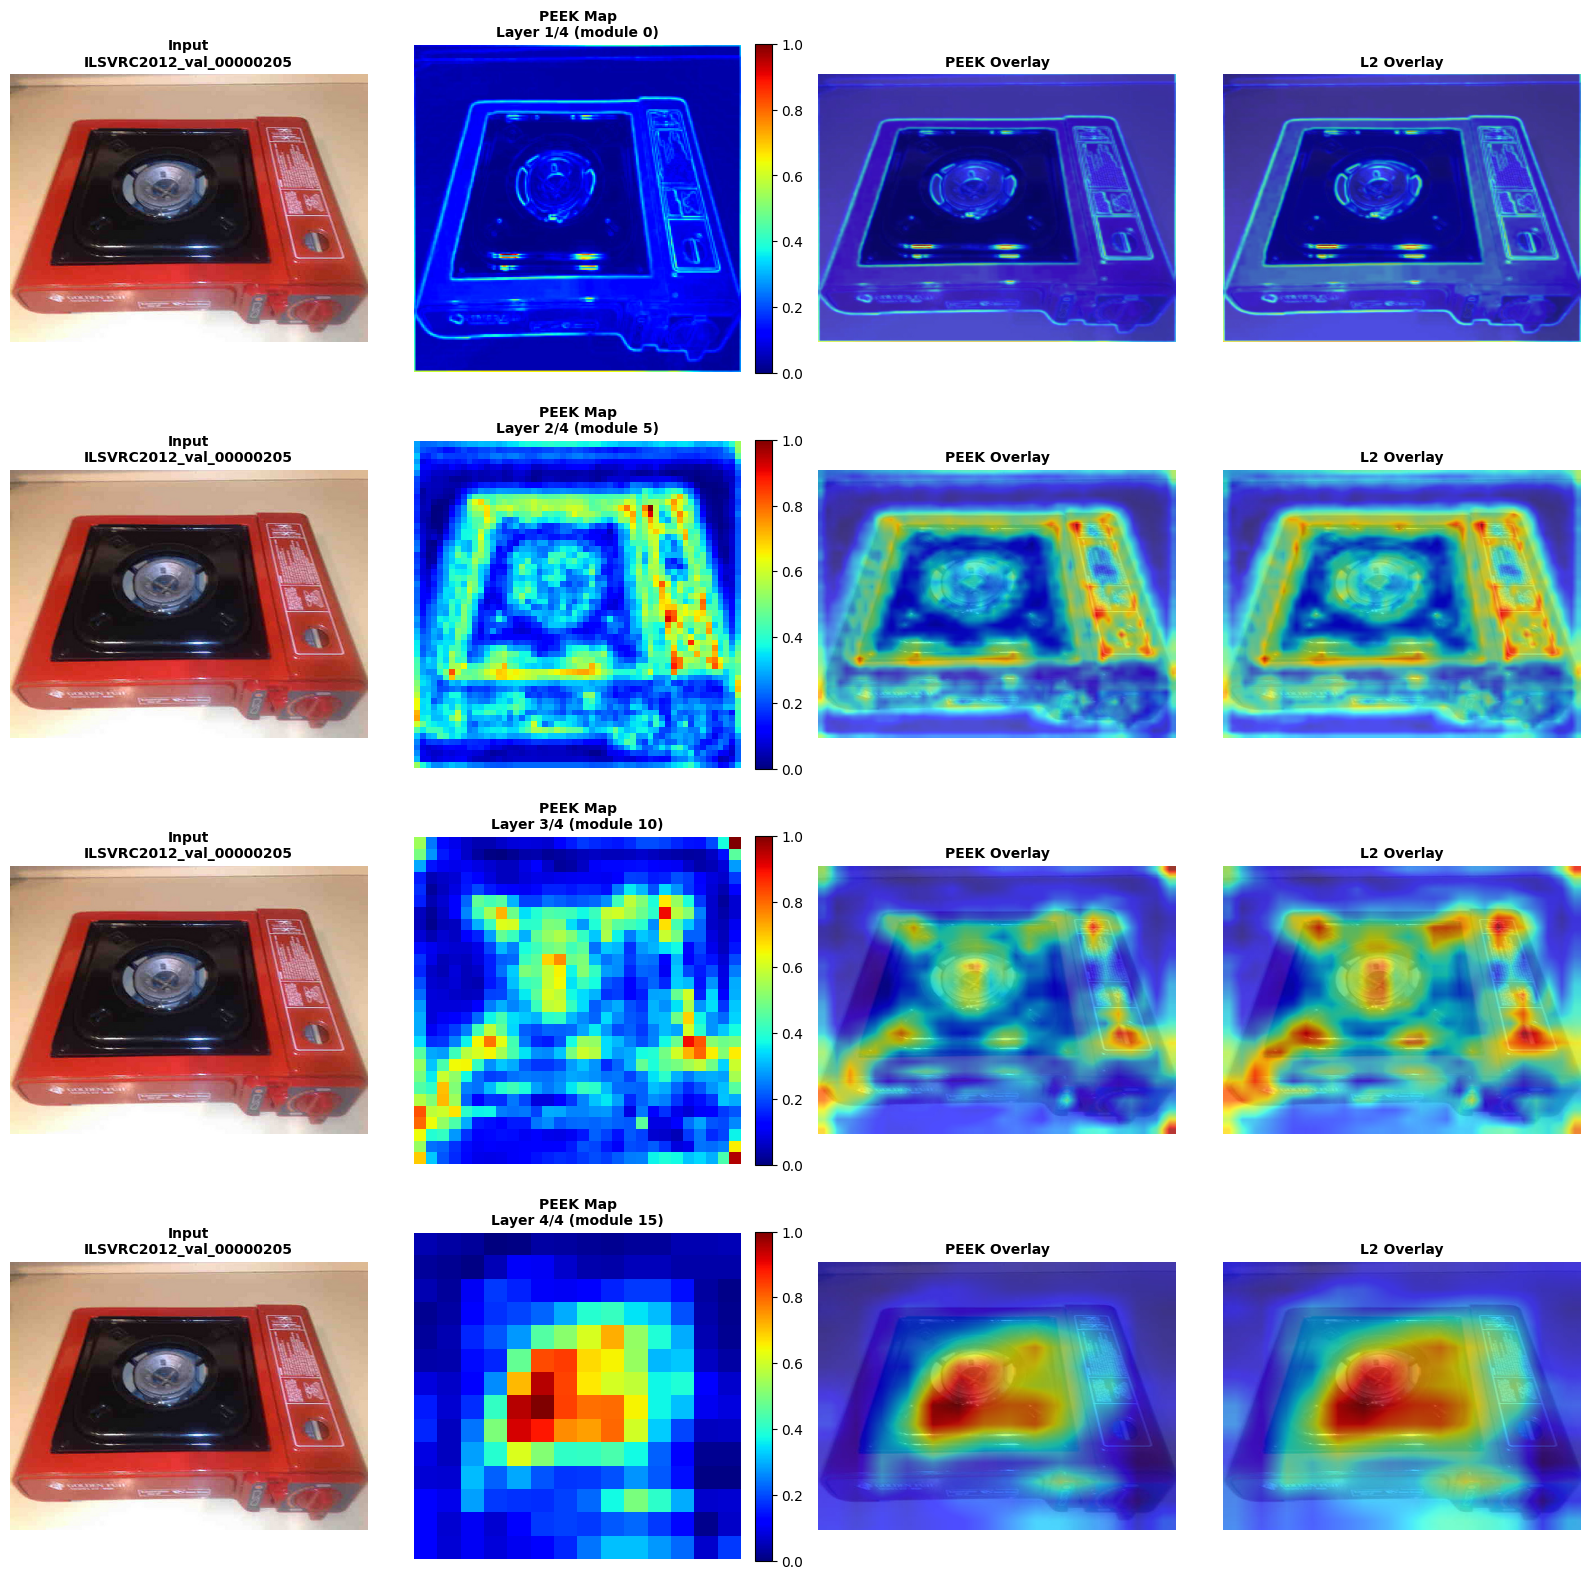

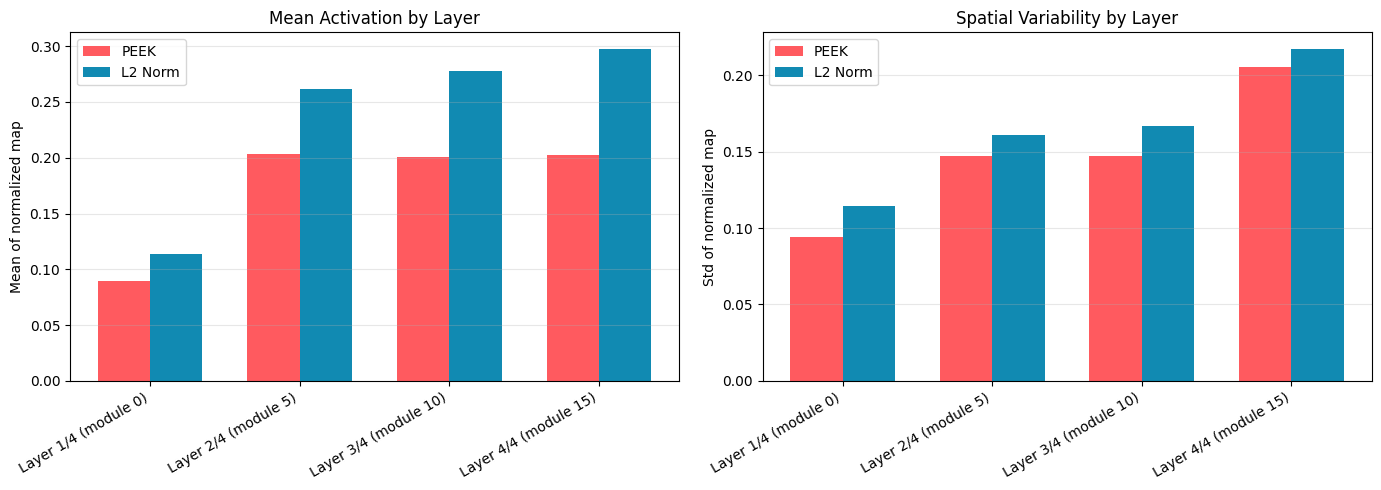

Saved multi-layer comparison to 'peek_vs_l2_multi_layer_comparison.png'
Saved multi-layer statistics to 'peek_vs_l2_multi_layer_statistics.png'


In [148]:
# Compare PEEK vs L2 across multiple representative layers
import pandas as pd

MULTI_LAYER_IMAGE_INDEX = 2
MULTI_LAYER_COUNT = 4

ref_img_path, ref_class_name = sample_images[MULTI_LAYER_IMAGE_INDEX]
ref_pkl_path = LATENTS_DIR / f"{ref_img_path.stem}.pkl"
ref_latents = load_latents_dict(ref_pkl_path)
selected_layers = select_representative_layers(ref_latents, n_layers=MULTI_LAYER_COUNT)

multi_layer_stats = []
for img_path, class_name in sample_images:
    pkl_path = LATENTS_DIR / f"{img_path.stem}.pkl"
    if not pkl_path.exists():
        continue

    latents_dict = load_latents_dict(pkl_path)
    for rank, layer_idx in enumerate(selected_layers):
        if layer_idx not in latents_dict:
            continue
        peek_map, l2_map = compute_maps_from_tensor(latents_dict[layer_idx])
        peek_norm = normalize_map(peek_map)
        l2_norm = normalize_map(l2_map)
        multi_layer_stats.append({
            'Image': class_name,
            'Layer Index': layer_idx,
            'Layer Label': format_layer_label(layer_idx, rank, len(selected_layers)),
            'PEEK Mean': compute_stats(peek_norm)['mean'],
            'L2 Mean': compute_stats(l2_norm)['mean'],
            'PEEK Std': compute_stats(peek_norm)['std'],
            'L2 Std': compute_stats(l2_norm)['std'],
        })

multi_layer_df = pd.DataFrame(multi_layer_stats)
layer_summary_df = multi_layer_df.groupby(['Layer Index', 'Layer Label'], as_index=False).mean(numeric_only=True)
print("Representative layers selected:")
for rank, layer_idx in enumerate(selected_layers):
    print(f"  - {format_layer_label(layer_idx, rank, len(selected_layers))}")

print(layer_summary_df.to_string(index=False))

ref_orig_img = Image.open(ref_img_path).convert('RGB')
layer_visuals = []
for rank, layer_idx in enumerate(selected_layers):
    peek_map, l2_map = compute_maps_from_tensor(ref_latents[layer_idx])
    peek_norm = normalize_map(peek_map)
    l2_norm = normalize_map(l2_map)
    layer_visuals.append({
        'label': format_layer_label(layer_idx, rank, len(selected_layers)),
        'peek_map': peek_norm,
        'l2_map': l2_norm,
    })

fig, axes = plt.subplots(len(layer_visuals), 4, figsize=(16, 4 * len(layer_visuals)))
if len(layer_visuals) == 1:
    axes = axes.reshape(1, -1)

for row_idx, layer_result in enumerate(layer_visuals):
    row_axes = axes[row_idx]
    peek_map = layer_result['peek_map']
    l2_map = layer_result['l2_map']
    layer_label = layer_result['label']

    row_axes[0].imshow(ref_orig_img)
    row_axes[0].set_title(f"Input\n{ref_class_name}", fontsize=10, fontweight='bold')
    row_axes[0].axis('off')

    im1 = row_axes[1].imshow(peek_map, cmap=CMAP_PEEK)
    row_axes[1].set_title(f"PEEK Map\n{layer_label}", fontsize=10, fontweight='bold')
    row_axes[1].axis('off')
    plt.colorbar(im1, ax=row_axes[1], fraction=0.046, pad=0.04)

    overlay_heatmap(row_axes[2], ref_orig_img, peek_map, cmap_name=CMAP_PEEK)
    row_axes[2].set_title('PEEK Overlay', fontsize=10, fontweight='bold')
    row_axes[2].axis('off')

    overlay_heatmap(row_axes[3], ref_orig_img, l2_map, cmap_name=CMAP_L2)
    row_axes[3].set_title('L2 Overlay', fontsize=10, fontweight='bold')
    row_axes[3].axis('off')

plt.tight_layout()
plt.savefig('peek_vs_l2_multi_layer_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
layer_positions = np.arange(len(layer_summary_df))
width = 0.35

axes[0].bar(layer_positions - width / 2, layer_summary_df['PEEK Mean'], width, label='PEEK', color='#ff5a5f')
axes[0].bar(layer_positions + width / 2, layer_summary_df['L2 Mean'], width, label='L2 Norm', color='#118ab2')
axes[0].set_title('Mean Activation by Layer')
axes[0].set_ylabel('Mean of normalized map')
axes[0].set_xticks(layer_positions)
axes[0].set_xticklabels(layer_summary_df['Layer Label'], rotation=30, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(layer_positions - width / 2, layer_summary_df['PEEK Std'], width, label='PEEK', color='#ff5a5f')
axes[1].bar(layer_positions + width / 2, layer_summary_df['L2 Std'], width, label='L2 Norm', color='#118ab2')
axes[1].set_title('Spatial Variability by Layer')
axes[1].set_ylabel('Std of normalized map')
axes[1].set_xticks(layer_positions)
axes[1].set_xticklabels(layer_summary_df['Layer Label'], rotation=30, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('peek_vs_l2_multi_layer_statistics.png', dpi=120, bbox_inches='tight')
plt.show()

print("Saved multi-layer comparison to 'peek_vs_l2_multi_layer_comparison.png'")
print("Saved multi-layer statistics to 'peek_vs_l2_multi_layer_statistics.png'")


## Why PEEK and L2 Disagree: Slope and Sharpness Analysis

Using the actual implementation in [core.py](/home/rwhite/Documents/PEEK/peek/core.py), PEEK first positivizes activations and then applies a pseudo-entropy-like nonlinearity directly to activations, not to a normalized channel distribution.

For a feature vector at one spatial location, let
$x = f + s + \varepsilon$ with $s = |\min(\text{feature map})|$ so that $x_c > 0$.

Then the two scores are:

- L2 norm: $L(f) = \sqrt{\sum_c f_c^2}$
- PEEK: $P(x) = -\sum_c \operatorname{entr}(x_c) = \sum_c x_c \log x_c$

Their slopes are:

- $\frac{\partial L}{\partial f_c} = \frac{f_c}{\|f\|_2}$
- $\frac{\partial P}{\partial x_c} = \log(x_c) + 1$

So the disagreement is mathematically different from Shannon entropy:

- L2 depends on relative magnitude through normalization by $\|f\|_2$.
- PEEK applies an elementwise nonlinear slope $\log(x_c)+1$ after positivity shift.
- There is no channel normalization term coupling all channels into a probability simplex.

This helps explain sharpness:

- For larger positive activations, $x \log x$ grows faster than linear, so strong responses are amplified more aggressively.
- Weaker activations contribute much less after the positivity shift and log nonlinearity.
- That can concentrate mass into tighter peaks, which visually looks sharper than L2.

The code below quantifies that with:

- a toy derivative comparison using the actual PEEK-style formula,
- a disagreement scatter between PEEK and L2,
- a sharpness metric based on average gradient magnitude,
- top-k concentration to show how spatial mass is distributed.

Toy slope comparison using the actual PEEK-style formula:
           Case   L2 Norm  PEEK Proxy  L2 Slope Max  PEEK Slope Max Positivized Activations
single-dominant 10.001500   22.390945       0.99985        3.312535   [10.1  0.2  0.2  0.2]
    distributed 10.000000   92.103404       0.50000        3.302585       [10. 10. 10. 10.]
          mixed  9.013878   25.567108       0.88752        3.140066       [8.5 4.5 1.5 1. ]

Measured disagreement and sharpness by layer:
          Layer Label  PEEK Mean  L2 Mean  PEEK Sharpness  L2 Sharpness  PEEK Top10% Mass  L2 Top10% Mass  Map Correlation  Sharpness Ratio (PEEK/L2)  Top10% Mass Ratio (PEEK/L2)
 Layer 1/4 (module 0)   0.089810 0.114011        0.027827      0.032996          0.321019        0.305667         0.966047                   0.843345                     1.050224
 Layer 2/4 (module 5)   0.285077 0.334892        0.081884      0.085081          0.213589        0.194521         0.991549                   0.962432                    

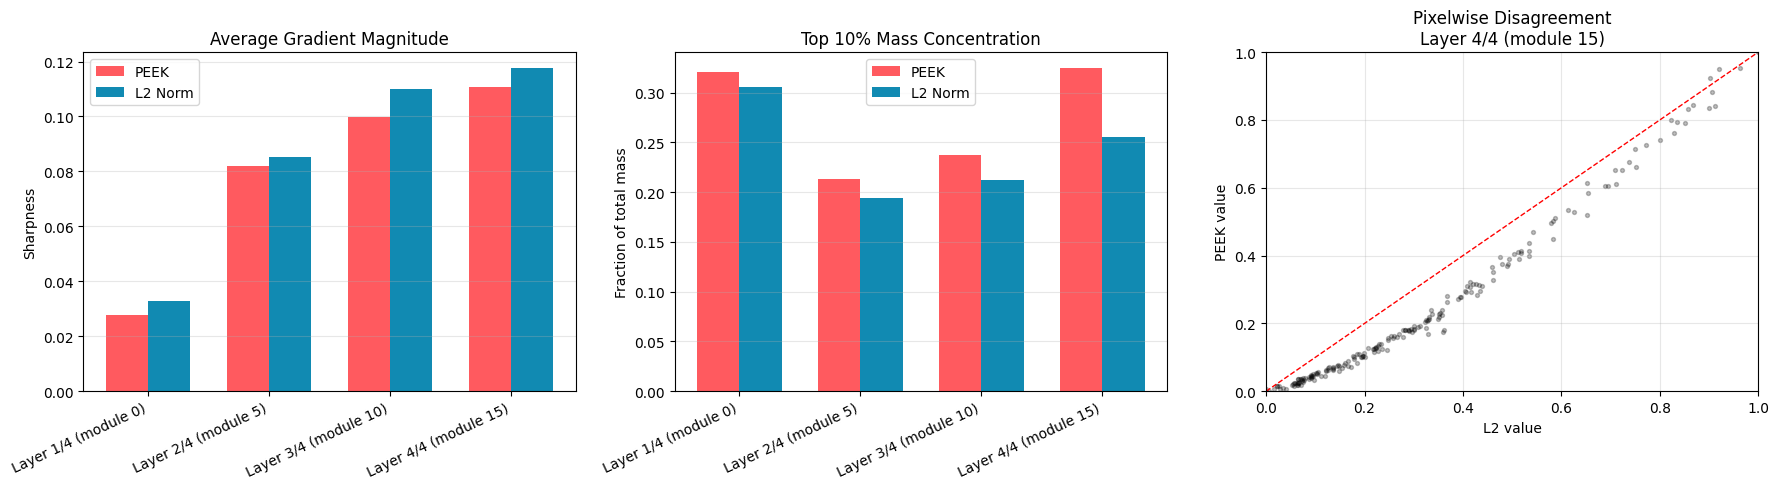


Interpretation:
- If PEEK sharpness > L2 sharpness, PEEK changes more abruptly in space, which matches a sharper map.
- If PEEK top-10% mass > L2 top-10% mass, PEEK concentrates activation into fewer pixels.
- If the scatter departs from the diagonal, the two scores disagree beyond simple rescaling.
Saved figure to 'peek_vs_l2_slope_sharpness_analysis.png'


In [149]:
import pandas as pd


def l2_slope(f):
    denom = np.linalg.norm(f) + 1e-12
    return f / denom


def positivize_vector(f, eps=1e-12):
    shift = float(np.abs(np.min(f)))
    return f + shift + eps


def peek_proxy_from_vector(f, eps=1e-12):
    x = positivize_vector(f, eps=eps)
    return float(np.sum(x * np.log(x)))


def peek_slope_from_vector(f, eps=1e-12):
    x = positivize_vector(f, eps=eps)
    return np.log(x) + 1.0


def gradient_sharpness(m):
    gy, gx = np.gradient(m)
    return float(np.mean(np.sqrt(gx ** 2 + gy ** 2)))


def topk_mass_fraction(m, frac=0.1):
    flat = np.sort(m.ravel())[::-1]
    k = max(1, int(len(flat) * frac))
    return float(flat[:k].sum() / (flat.sum() + 1e-12))


toy_vectors = {
    'single-dominant': np.array([10.0, 0.1, 0.1, 0.1]),
    'distributed': np.array([5.0, 5.0, 5.0, 5.0]),
    'mixed': np.array([8.0, 4.0, 1.0, 0.5]),
}

toy_rows = []
for name, f in toy_vectors.items():
    x = positivize_vector(f)
    l2_grad = l2_slope(f)
    peek_grad = peek_slope_from_vector(f)
    toy_rows.append({
        'Case': name,
        'L2 Norm': float(np.linalg.norm(f)),
        'PEEK Proxy': float(peek_proxy_from_vector(f)),
        'L2 Slope Max': float(np.max(np.abs(l2_grad))),
        'PEEK Slope Max': float(np.max(np.abs(peek_grad))),
        'Positivized Activations': np.array2string(x, precision=3),
    })

toy_df = pd.DataFrame(toy_rows)
print('Toy slope comparison using the actual PEEK-style formula:')
print(toy_df.to_string(index=False))

analysis_image_index = min(2, len(sample_images) - 1)
analysis_img_path, analysis_class_name = sample_images[analysis_image_index]
analysis_pkl_path = LATENTS_DIR / f"{analysis_img_path.stem}.pkl"
analysis_latents = load_latents_dict(analysis_pkl_path)
analysis_layers = select_representative_layers(analysis_latents, n_layers=4)

rows = []
scatter_peek = None
scatter_l2 = None
scatter_label = None

for rank, layer_idx in enumerate(analysis_layers):
    peek_map, l2_map = compute_maps_from_tensor(analysis_latents[layer_idx])
    peek_norm = normalize_map(peek_map)
    l2_norm = normalize_map(l2_map)
    label = format_layer_label(layer_idx, rank, len(analysis_layers))
    rows.append({
        'Layer Label': label,
        'PEEK Mean': float(peek_norm.mean()),
        'L2 Mean': float(l2_norm.mean()),
        'PEEK Sharpness': gradient_sharpness(peek_norm),
        'L2 Sharpness': gradient_sharpness(l2_norm),
        'PEEK Top10% Mass': topk_mass_fraction(peek_norm, frac=0.1),
        'L2 Top10% Mass': topk_mass_fraction(l2_norm, frac=0.1),
        'Map Correlation': float(np.corrcoef(peek_norm.ravel(), l2_norm.ravel())[0, 1]),
    })
    if rank == len(analysis_layers) - 1:
        scatter_peek = peek_norm.ravel()
        scatter_l2 = l2_norm.ravel()
        scatter_label = label

analysis_df = pd.DataFrame(rows)
analysis_df['Sharpness Ratio (PEEK/L2)'] = analysis_df['PEEK Sharpness'] / (analysis_df['L2 Sharpness'] + 1e-12)
analysis_df['Top10% Mass Ratio (PEEK/L2)'] = analysis_df['PEEK Top10% Mass'] / (analysis_df['L2 Top10% Mass'] + 1e-12)

linear_coef = np.polyfit(scatter_l2, scatter_peek, deg=1)
quadratic_coef = np.polyfit(scatter_l2, scatter_peek, deg=2)
linear_pred = np.polyval(linear_coef, scatter_l2)
quadratic_pred = np.polyval(quadratic_coef, scatter_l2)
linear_rmse = float(np.sqrt(np.mean((scatter_peek - linear_pred) ** 2)))
quadratic_rmse = float(np.sqrt(np.mean((scatter_peek - quadratic_pred) ** 2)))
fit_grid = np.linspace(0, 1, 400)
linear_curve = np.polyval(linear_coef, fit_grid)
quadratic_curve = np.polyval(quadratic_coef, fit_grid)

print('\nMeasured disagreement and sharpness by layer:')
print(analysis_df.to_string(index=False))
print('\nScatter-fit diagnostics:')
print(f'  Linear fit coefficients: slope={linear_coef[0]:.4f}, intercept={linear_coef[1]:.4f}')
print(f'  Quadratic fit coefficients: a={quadratic_coef[0]:.4f}, b={quadratic_coef[1]:.4f}, c={quadratic_coef[2]:.4f}')
print(f'  Linear RMSE:    {linear_rmse:.6f}')
print(f'  Quadratic RMSE: {quadratic_rmse:.6f}')

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

x = np.arange(len(analysis_df))
width = 0.35

axes[0].bar(x - width / 2, analysis_df['PEEK Sharpness'], width, label='PEEK', color='#ff5a5f')
axes[0].bar(x + width / 2, analysis_df['L2 Sharpness'], width, label='L2 Norm', color='#118ab2')
axes[0].set_title('Average Gradient Magnitude')
axes[0].set_ylabel('Sharpness')
axes[0].set_xticks(x)
axes[0].set_xticklabels(analysis_df['Layer Label'], rotation=25, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width / 2, analysis_df['PEEK Top10% Mass'], width, label='PEEK', color='#ff5a5f')
axes[1].bar(x + width / 2, analysis_df['L2 Top10% Mass'], width, label='L2 Norm', color='#118ab2')
axes[1].set_title('Top 10% Mass Concentration')
axes[1].set_ylabel('Fraction of total mass')
axes[1].set_xticks(x)
axes[1].set_xticklabels(analysis_df['Layer Label'], rotation=25, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].scatter(scatter_l2, scatter_peek, s=8, alpha=0.18, color='black')
lims = [0, 1]
axes[2].plot(lims, lims, linestyle='--', color='red', linewidth=1)
axes[2].plot(fit_grid, linear_curve, color='#118ab2', linewidth=2, label=f'Linear RMSE={linear_rmse:.4f}')
axes[2].plot(fit_grid, quadratic_curve, color='#ff5a5f', linewidth=2, label=f'Quadratic RMSE={quadratic_rmse:.4f}')
axes[2].set_xlim(lims)
axes[2].set_ylim(lims)
axes[2].set_xlabel('L2 value')
axes[2].set_ylabel('PEEK value')
axes[2].set_title(f'Pixelwise Disagreement\n{scatter_label}')
axes[2].grid(alpha=0.3)
axes[2].legend()

axes[3].scatter(scatter_l2, scatter_peek - linear_pred, s=8, alpha=0.18, color='#118ab2', label='Linear residuals')
axes[3].scatter(scatter_l2, scatter_peek - quadratic_pred, s=8, alpha=0.18, color='#ff5a5f', label='Quadratic residuals')
axes[3].axhline(0, linestyle='--', color='black', linewidth=1)
axes[3].set_xlim(lims)
axes[3].set_xlabel('L2 value')
axes[3].set_ylabel('Residual')
axes[3].set_title('Residual Comparison')
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig('peek_vs_l2_slope_sharpness_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- If PEEK sharpness > L2 sharpness, PEEK changes more abruptly in space, which matches a sharper map.")
print("- If PEEK top-10% mass > L2 top-10% mass, PEEK concentrates activation into fewer pixels.")
print("- If the scatter departs from the diagonal, the two scores disagree beyond simple rescaling.")
print("- If the quadratic RMSE is lower than the linear RMSE, the PEEK-vs-L2 relationship is genuinely curved rather than approximately linear.")
print("Saved figure to 'peek_vs_l2_slope_sharpness_analysis.png'")
